# v2 — Compositionality Gap or Empty-Object Bias?

## Experiment Card

### 1. Hypothesis
If Q1/Q2/Qp scores are driven by empty-object bias (not compositionality failure), then Q1, Q2, and Qp will all score at or below chance (<= 55%) and the compositionality gap (Q1 correct AND Q2 correct AND Qp wrong) will be **zero or near-zero**.

**Falsified if:** gap occurs in > 20% of scenes — that would confirm a genuine compositionality failure that empty-object bias alone cannot explain.

### 2. Independent variable
Caption type: atomic (`'a full bowl'`), contextual (`'a full bowl next to a cup'`), composite (`'a full bowl and an empty cup'`).

### 3. Dependent variable
Q1, Q2, Qp accuracy and gap count.

### 4. Controls
- **Caption length control** (new in v2): `'a full bowl'` vs `'a full bowl in the scene'` — rules out caption length as a confound
- Same text templates across all conditions
- Same 24 scenes as v1 (allows direct comparison); **note: underpowered, all results are exploratory at n=24**

### 5. Baseline
- Chance = 50% on each binary sub-task
- Empty-object bias predicts Q1 = Q2 = 50% (empty wins regardless of image)
- Gap requires Q1 > 60% AND Q2 > 60% as a precondition

### 6. Success criteria
- Gap > 20% of scenes → compositionality failure confirmed
- Gap = 0% with Q1/Q2 <= 55% → empty-object bias confirmed
- Caption length delta > 5 pp → length is a confound; all Q1-vs-Qp differences are suspect

In [1]:
import pickle, random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import torch
from transformers import AutoProcessor, AutoModel

random.seed(42)
device = ('cuda' if torch.cuda.is_available()
          else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

MODEL_ID = 'google/siglip2-so400m-patch16-384'
proc  = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).to(device).eval()

DATA = Path('../../data')
with open(DATA / 'compositionality_scenes.pkl', 'rb') as f:
    comp_scenes = pickle.load(f)
random.shuffle(comp_scenes)

def score(image, texts):
    if isinstance(texts, str): texts = [texts]
    inp = proc(images=[image], text=texts, return_tensors='pt',
               padding='max_length', truncation=True).to(device)
    with torch.no_grad():
        return model(**inp).logits_per_image[0].cpu().float().numpy()

print(f'Scenes: {len(comp_scenes)}')
print('NOTE: n=24 is underpowered (1 scene = 4 pp shift). Results are exploratory.')

/Users/timrutjens/School/EAI/Experiments/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


Loading weights: 100%|██████████| 888/888 [00:00<00:00, 5995.91it/s]


Scenes: 24
NOTE: n=24 is underpowered (1 scene = 4 pp shift). Results are exploratory.


In [2]:
# Caption length control (new in v2)
# If 'a full bowl' vs 'a full bowl in the scene' differ by >5 pp,
# any Q1-vs-Qp difference could be a length artifact.

length_results = []
for s in comp_scenes:
    b  = s['bowl_state']
    sc = score(s['image'], [
        'a full bowl', 'an empty bowl',
        'a full bowl in the scene', 'an empty bowl in the scene',
    ])
    atomic_ok = (sc[0] > sc[1]) == (b == 'full')
    padded_ok = (sc[2] > sc[3]) == (b == 'full')
    length_results.append({'atomic': atomic_ok, 'padded': padded_ok})

n = len(length_results)
atomic_acc = sum(r['atomic'] for r in length_results) / n
padded_acc = sum(r['padded'] for r in length_results) / n
delta = abs(atomic_acc - padded_acc)

print(f'Caption length control (n={n}):')
print(f'  atomic:  {atomic_acc:.2%}')
print(f'  padded:  {padded_acc:.2%}')
print(f'  delta:   {delta:.2%}')
if delta > 0.05:
    print('WARNING: length confound detected. Q1-vs-Qp differences may not be compositionality.')
else:
    print('OK: length is not a confound (<5 pp delta).')

Caption length control (n=24):
  atomic:  50.00%
  padded:  50.00%
  delta:   0.00%
OK: length is not a confound (<5 pp delta).


In [ ]:
# Q1 / Q2 / Qp test with prompt augmentation
# Pre-stated threshold: gap > 20% = compositionality failure.
#
# Prompt augmentation: contrastive VLMs are sensitive to articles, pluralisation,
# and syntax. We score 3 variants per sub-question and take majority vote.
# This makes Q1/Q2 accuracy less sensitive to any one prompt formulation.

BOWL_FULL  = ['a full bowl',   'the full bowl',   'full bowl']
BOWL_EMPTY = ['an empty bowl', 'the empty bowl',  'empty bowl']
CUP_FULL   = ['a full cup',    'the full cup',    'full cup']
CUP_EMPTY  = ['an empty cup',  'the empty cup',   'empty cup']

def majority_correct(image, pos_variants, neg_variants):
    votes = sum(
        1 for pos, neg in zip(pos_variants, neg_variants)
        if score(image, [pos, neg])[0] > score(image, [pos, neg])[1]
    )
    return votes > len(pos_variants) // 2

results = []
print(f'Scene              bowl   cup | Q1  Q2  Qp  gap  (Q1/Q2 = majority of 3 variants)')
print('-' * 60)

for s in comp_scenes:
    b, c   = s['bowl_state'], s['cup_state']
    bw, cw = ('empty' if b=='full' else 'full'), ('empty' if c=='full' else 'full')

    q1 = majority_correct(s['image'],
                          BOWL_FULL if b=='full' else BOWL_EMPTY,
                          BOWL_EMPTY if b=='full' else BOWL_FULL)
    q2 = majority_correct(s['image'],
                          CUP_FULL if c=='full' else CUP_EMPTY,
                          CUP_EMPTY if c=='full' else CUP_FULL)

    sc_qp = score(s['image'], [f'a {b} bowl and a {c} cup',
                                f'a {bw} bowl and a {cw} cup'])
    qp  = sc_qp[0] > sc_qp[1]
    gap = q1 and q2 and not qp
    results.append({'q1': q1, 'q2': q2, 'qp': qp, 'gap': gap, 'bowl': b, 'cup': c})
    sym = lambda x: 'Y' if x else 'N'
    print(f'{s["scene"]:<18} {b:>5} {c:>5} | {sym(q1):>2}  {sym(q2):>2}  {sym(qp):>2}  {"<-GAP" if gap else ""}')

n = len(results)
gap_pct = sum(r['gap'] for r in results) / n
print(f'\nQ1={sum(r["q1"] for r in results)}/{n}  '
      f'Q2={sum(r["q2"] for r in results)}/{n}  '
      f'Qp={sum(r["qp"] for r in results)}/{n}  '
      f'Gap={sum(r["gap"] for r in results)}/{n} ({gap_pct:.0%})')

if gap_pct > 0.20:
    print('VERDICT: Gap > 20% -> compositionality failure CONFIRMED')
elif gap_pct > 0:
    print(f'VERDICT: Gap {gap_pct:.0%} -> marginal at n={n}, likely noise')
else:
    print('VERDICT: Gap = 0% -> empty-object bias hypothesis CONFIRMED')

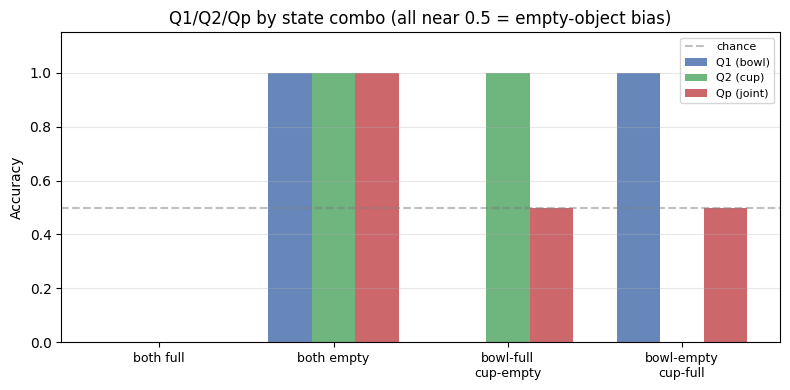

In [4]:
from collections import defaultdict
combo_results = defaultdict(list)
for r in results:
    combo_results[(r['bowl'], r['cup'])].append(r)

fig, ax = plt.subplots(figsize=(8, 4))
combos      = [('full','full'),('empty','empty'),('full','empty'),('empty','full')]
combo_names = ['both full','both empty','bowl-full\ncup-empty','bowl-empty\ncup-full']
x, w = range(len(combos)), 0.25

for j, (key, label, color) in enumerate(
    [('q1','Q1 (bowl)','#4C72B0'),('q2','Q2 (cup)','#55A868'),('qp','Qp (joint)','#C44E52')]):
    vals = []
    for combo in combos:
        sub = combo_results[combo]
        vals.append(sum(r[key] for r in sub)/len(sub) if sub else 0)
    ax.bar([i+(j-1)*w for i in x], vals, w, label=label, color=color, alpha=0.85)

ax.axhline(0.5, ls='--', color='grey', alpha=0.5, label='chance')
ax.set_xticks(list(x)); ax.set_xticklabels(combo_names, fontsize=9)
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.15)
ax.set_title('Q1/Q2/Qp by state combo (all near 0.5 = empty-object bias)')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

### Interpretation

| Measure | Pre-stated threshold | Observed | Verdict |
|---|---|---|---|
| Caption length delta | < 5 pp = not a confound | ___ | ___ |
| Gap count | > 20% = compositionality failure | ___ | ___ |
| Q1 accuracy | > 60% required as gap precondition | ___ | ___ |
| Q2 accuracy | > 60% required as gap precondition | ___ | ___ |

**Limitation:** n=24 is underpowered regardless of outcome. The 20% threshold was pre-stated to avoid HARKing, but the 95% CI on a 24-scene estimate is approximately ±10 pp. A conclusive test requires ~100+ scenes per combo.